# EDA

# Imports

In [39]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Quality Assessment

In [ ]:
df = pd.read_csv(os.path.join('..', 'data', 'diabetic_data.csv'))
print(f'{df.shape[0]} rows and {df.shape[1]} columns')
df.head()

In [ ]:
len(df['patient_nbr'].unique()) #são 71518 pacientes, cerca 30000 saídas do hospital são de pacientes que foram readmitidos

In [ ]:
df.select_dtypes(include='number').info() #somente variaveis numericas

In [ ]:
df.select_dtypes(include='object').columns #variaveis categoricas

In [ ]:
null_counts = df.isnull().sum() # contagem de valores nulos por coluna, observamos que os valores nulos são muito altos, logo podemos retirar as colunas com muitos valores nulos
df_null_counts = null_counts[null_counts > 0]
df_null_counts

In [ ]:
df = df.drop(columns=df_null_counts.index) #removendo colunas com muitos valores nulos para melhorar a qualidade da análise
df

In [ ]:
df[df.duplicated()] #não há duplicações no dataset

## Numeric Analyses

In [ ]:
numerical_columns = df.select_dtypes(include='number').columns #descrição estatística das variáveis numéricas
numerical_columns = numerical_columns.drop(['patient_nbr','admission_type_id','encounter_id','admission_source_id','discharge_disposition_id','admission_source_id']) #removendo a coluna de id, pois não é relevante para a análise
numerical_df = df[numerical_columns]
numerical_df.describe()

In [ ]:

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, kde=True, hue='readmitted') 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
pd.plotting.scatter_matrix(df[numerical_columns], figsize=(12, 12), diagonal='kde', alpha=0.5, marker='o')
plt.suptitle('Matriz de Dispersão (Pandas)', y=1.02, fontsize=16)
plt.show()

In [ ]:
matrix_corr = numerical_df.corr(method='spearman') #matriz de correlação entre as variáveis numéricas utilizando o método de Spearman, que é mais adequado para não linearidades e dados com outliers
g = sns.clustermap( #mapa com uso de clusterização hierárquica para organizar as variáveis de acordo com suas correlações, facilitando a visualização de padrões
    matrix_corr,
    figsize=(7,7),     
    cmap='Spectral',           
    center=0,              
    annot=False,           
    fmt='.2f',            
    linewidths=.75,      
    cbar_kws={"shrink": .5} 
)

In [ ]:
n = len(numerical_columns)
coluna_hue = 'readmitted'
categorias = df[coluna_hue].dropna().unique()

cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'] 

fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i, col_y in enumerate(numerical_columns):
    for j, col_x in enumerate(numerical_columns):
        ax = axes[i, j]
        
        for idx, cat in enumerate(categorias):
            subset = df[df[coluna_hue] == cat]
            
            cor_atual = cores[idx % len(cores)]
            
            if i == j:
                ax.hist(subset[col_x].dropna(), bins=15, color=cor_atual, alpha=0.5, label=cat)
            else:
                ax.scatter(subset[col_x], subset[col_y], color=cor_atual, alpha=0.5, s=15, label=cat)
        
        if i < n - 1:
            ax.set_xticks([]) 
        else:
            ax.set_xlabel(col_x, fontsize=10)
            ax.tick_params(axis='x', rotation=45)
            
        if j > 0:
            ax.set_yticks([]) 
        else:
            ax.set_ylabel(col_y, fontsize=10)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title=coluna_hue, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1) 
plt.show()

## Categorical Analyses

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns #descrição estatística das variáveis categóricas
categorical_df = df[categorical_columns]
categorical_df.describe()

In [ ]:
columns_question = categorical_df.apply(lambda col: (col == '?').sum()) #contagem de valores '?' em cada coluna categórica, indicando a quantidade de dados faltantes representados por '?'
columns_question #altos '?' indica falta de dados e ruídos, devem ser retiradas colunas com muitos '?' para melhorar a qualidade da análise

In [ ]:
categorical_df[categorical_df.columns[columns_question > 0]]

In [ ]:
categorical_df = categorical_df.drop(columns=['weight','medical_specialty','payer_code']) #removendo colunas com muitos '?' para melhorar a qualidade da análise, número de corte escolhido foi 2273
categorical_df

In [ ]:
categorical_columns = categorical_df.columns
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=categorical_df, x=col) #gráfico de barras para visualizar a distribuição das categorias em cada coluna categórica
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45) #rotaciona os rótulos do eixo x para melhor visualização
    plt.show()
    
#valores muito ruidosos, muitas categorias com poucos registros, dificultam a análise, retiramos eles, assim como aqueles que possuem um único registro

In [ ]:
cols_to_drop = ['diag_1', 'diag_2', 'diag_3', 'examide', 'citoglipton'] #colunas de altissima variação ou nenhuma variação
categorical_df = categorical_df.drop(columns=cols_to_drop)
categorical_df

In [ ]:
n=4

tuples = []

for col1 in categorical_df.columns:
    for col2 in categorical_df.columns:
        if col1 != col2 and ((col1, col2) not in tuples or (col2, col1) not in tuples) and ((len(categorical_df[col1].value_counts().index) > n and len(categorical_df[col2].value_counts().index) > n) or col1 == 'readmitted' or col2 == 'readmitted'): 
            tuples.append((col1, col2))
            tuples.append((col2, col1))
            try:
                plt.figure(figsize=(6,4))
                sns.countplot(data=categorical_df, x=col1, hue=col2) #gráfico de barras para visualizar a relação entre duas variáveis categóricas, usando a variável col2 para colorir as barras de acordo com suas categorias
                plt.title(f'Count of {col1} by {col2}')
                plt.xlabel(col1)
                plt.ylabel('Count')
                plt.xticks(rotation=45) #rotaciona os rótulos do eixo x para melhor visualização
                plt.legend(title=col2) #adiciona uma legenda para identificar as categorias da variável col2
                plt.show()
            except ValueError:
                print(f"Cannot plot {col1} vs {col2} due to too many categories.")
                continue
            

## Bivariate Analysis (Categorical and Numerical)

In [ ]:
df = numerical_df.join(categorical_df)
df

In [ ]:
n = 4
tuples = []

for col1 in numerical_df.columns:
    for col2 in categorical_df.columns:
        if col1 != col2 and ((col1, col2) not in tuples or (col2, col1) not in tuples) and ((len(categorical_df[col2].value_counts().index) > n)):
            tuples.append((col1, col2))
            tuples.append((col2, col1))
            
            plt.figure(figsize=(10, 6)) 
            
            sns.boxplot(data=df, x=col2, y=col1, hue='readmitted', fill=False, gap=.1)
            
            plt.title(f'Relação entre {col1} e {col2}') 
            
            plt.show()

In [ ]:

def permutation_test(group1, group2, n_permutations=1000): #teste de permutação para comparar a diferença das médias entre dois grupos, retornando a diferença observada e o p-valor
    obs_diff = np.abs(np.mean(group1) - np.mean(group2))
    combined = np.concatenate([group1, group2])
    n_group1 = len(group1)
    
    extreme_count = 0
    
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        pseudo_group1 = combined[:n_group1]
        pseudo_group2 = combined[n_group1:]
        pseudo_diff = np.abs(np.mean(pseudo_group1) - np.mean(pseudo_group2))
        
        if pseudo_diff >= obs_diff:
            extreme_count += 1
            
    p_value = (extreme_count + 1) / (n_permutations + 1)
    
    return obs_diff, p_value

In [ ]:
target_group_full = df[df['readmitted'] == '<30']
control_group_full = df[df['readmitted'] != '<30']

results = []
sample_size = 1000 #amostra de 2000 pacientes para cada grupo, garantindo uma análise estatística robusta sem sobrecarregar o processamento

for col in numerical_columns:
    target_vals = target_group_full[col].dropna().values
    control_vals = control_group_full[col].dropna().values
    
    if len(target_vals) >= sample_size and len(control_vals) >= sample_size:
        target_sample = np.random.choice(target_vals, size=sample_size, replace=False)
        control_sample = np.random.choice(control_vals, size=sample_size, replace=False)
        
        obs_diff, p_val = permutation_test(target_sample, control_sample, n_permutations=1000)
        
        results.append({
            'Variable': col,
            'Mean <30 (Sample)': np.mean(target_sample),
            'Mean Others (Sample)': np.mean(control_sample),
            'Difference (Abs)': obs_diff,
            'P-Value': p_val,
            'Significant (α=0.05)': p_val < 0.05
        })

results_df_less = pd.DataFrame(results)
display(results_df_less)

In [ ]:
target_group_full = df[df['readmitted'] == '>30']
control_group_full = df[df['readmitted'] != '>30']

results = []
sample_size = 1000 #amostra de 2000 pacientes para cada grupo, garantindo uma análise estatística robusta sem sobrecarregar o processamento

for col in numerical_columns:
    target_vals = target_group_full[col].dropna().values
    control_vals = control_group_full[col].dropna().values
    
    if len(target_vals) >= sample_size and len(control_vals) >= sample_size:
        target_sample = np.random.choice(target_vals, size=sample_size, replace=False)
        control_sample = np.random.choice(control_vals, size=sample_size, replace=False)
        
        obs_diff, p_val = permutation_test(target_sample, control_sample, n_permutations=1000)
        
        results.append({
            'Variable': col,
            'Mean >30 (Sample)': np.mean(target_sample),
            'Mean Others (Sample)': np.mean(control_sample),
            'Difference (Abs)': obs_diff,
            'P-Value': p_val,
            'Significant (α=0.05)': p_val < 0.05
        })

results_df_higher = pd.DataFrame(results)
display(results_df_higher)

In [ ]:
target_group_full = df[df['readmitted'] == 'NO']
control_group_full = df[df['readmitted'] != 'NO']

results = []
sample_size = 1000 #amostra de 2000 pacientes para cada grupo, garantindo uma análise estatística robusta sem sobrecarregar o processamento

for col in numerical_columns:
    target_vals = target_group_full[col].dropna().values
    control_vals = control_group_full[col].dropna().values
    
    if len(target_vals) >= sample_size and len(control_vals) >= sample_size:
        target_sample = np.random.choice(target_vals, size=sample_size, replace=False)
        control_sample = np.random.choice(control_vals, size=sample_size, replace=False)
        
        obs_diff, p_val = permutation_test(target_sample, control_sample, n_permutations=1000)
        
        results.append({
            'Variable': col,
            'Mean NO (Sample)': np.mean(target_sample),
            'Mean Others (Sample)': np.mean(control_sample),
            'Difference (Abs)': obs_diff,
            'P-Value': p_val,
            'Significant (α=0.05)': p_val < 0.05
        })

results_df_no = pd.DataFrame(results)
display(results_df_no)

In [37]:
resultados_cat = []

for col in categorical_df.columns:
    if col != 'readmitted':
        tabela = pd.crosstab(categorical_df[col], categorical_df['readmitted'])
        chi2, p_val, dof, expected = chi2_contingency(tabela)
        
        resultados_cat.append({
            'Variável': col,
            'P-Valor': p_val,
            'Significativo (α=0.05)': p_val < 0.05
        })

display(pd.DataFrame(resultados_cat).sort_values(by='P-Valor'))

,Variável,P-Valor,Significativo (α=0.05)
18,insulin,2.126586e-108,True
25,diabetesMed,1.175514e-84,True
2,age,9.348415e-56,True
0,race,7.379469e-55,True
24,change,1.362061e-47,True
3,metformin,2.445917e-20,True
4,repaglinide,7.302647e-11,True
9,glipizide,6.551146e-10,True
13,rosiglitazone,1.161873e-07,True
1,gender,1.447272e-07,True


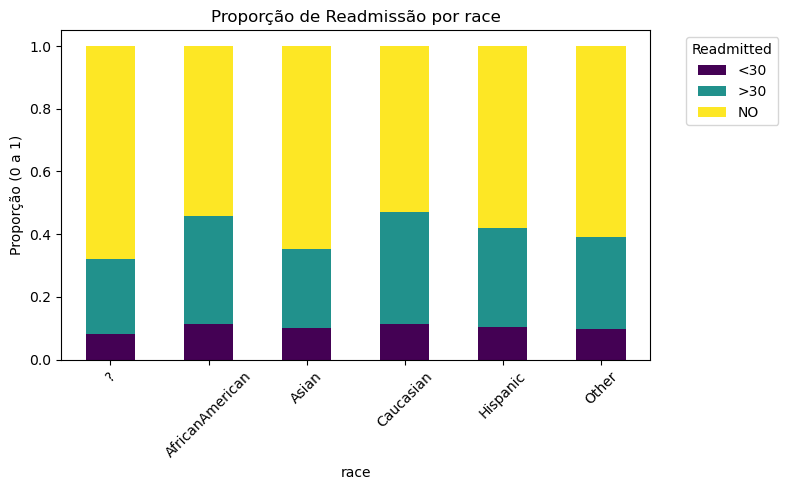

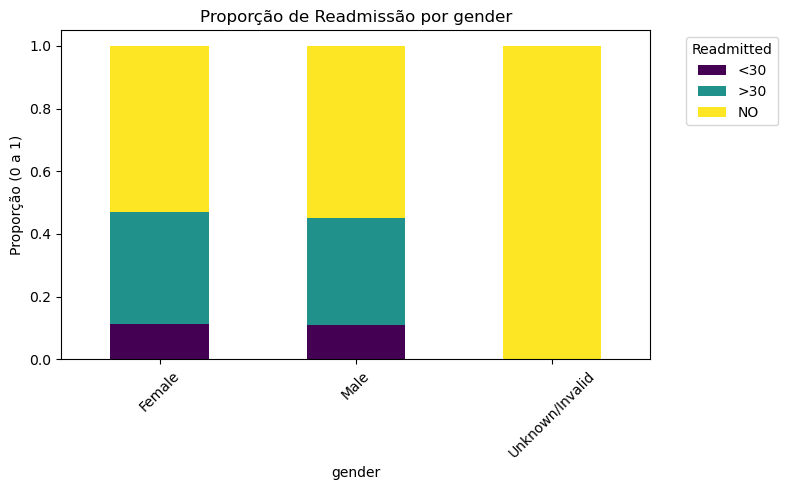

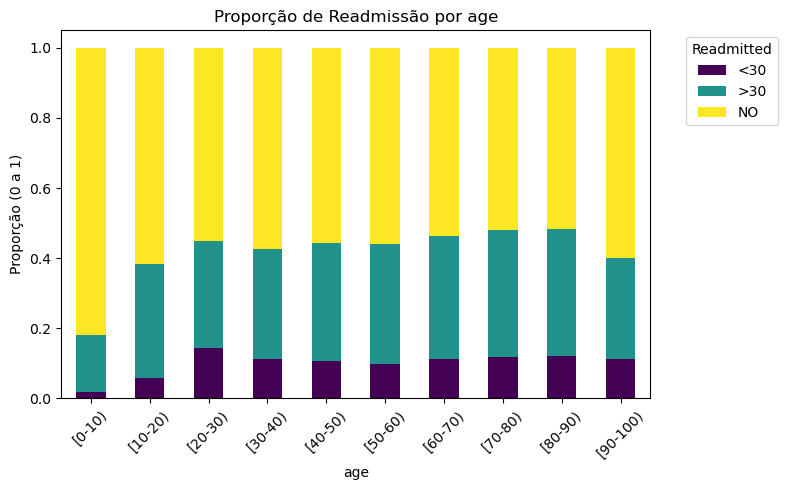

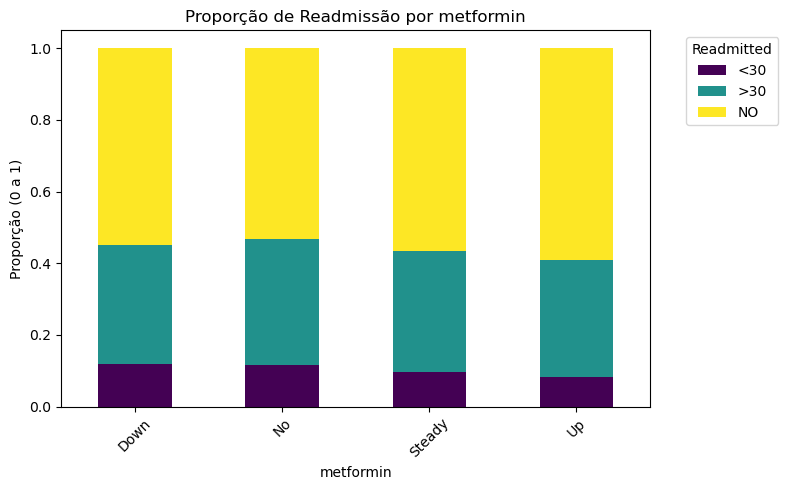

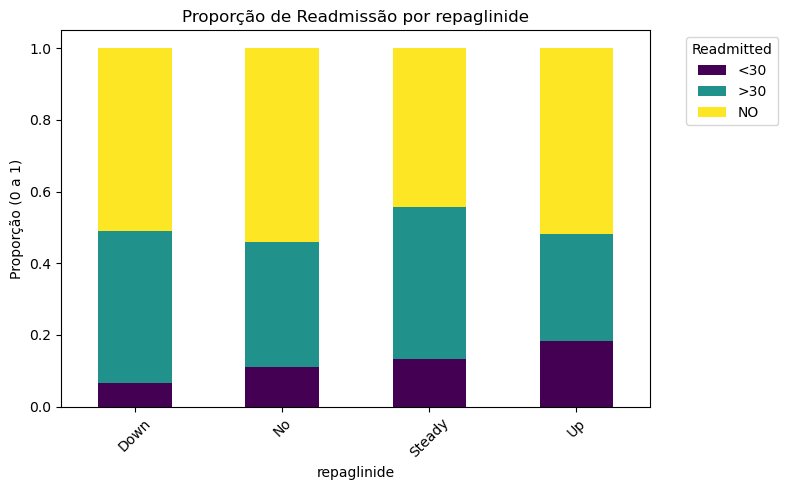

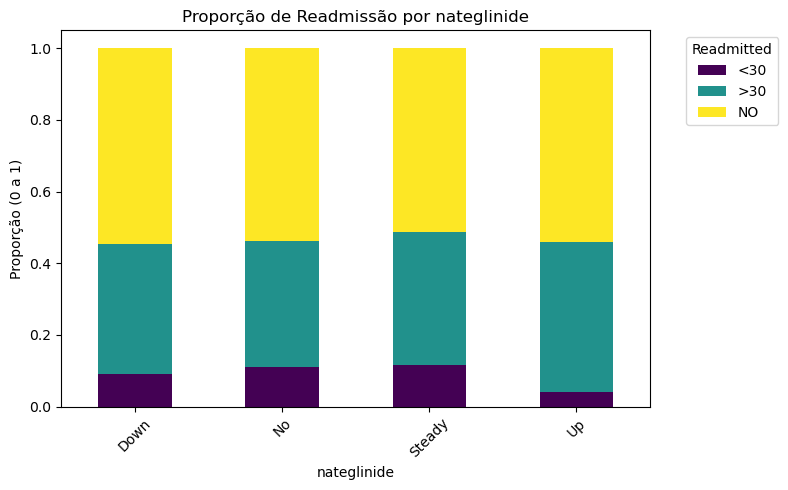

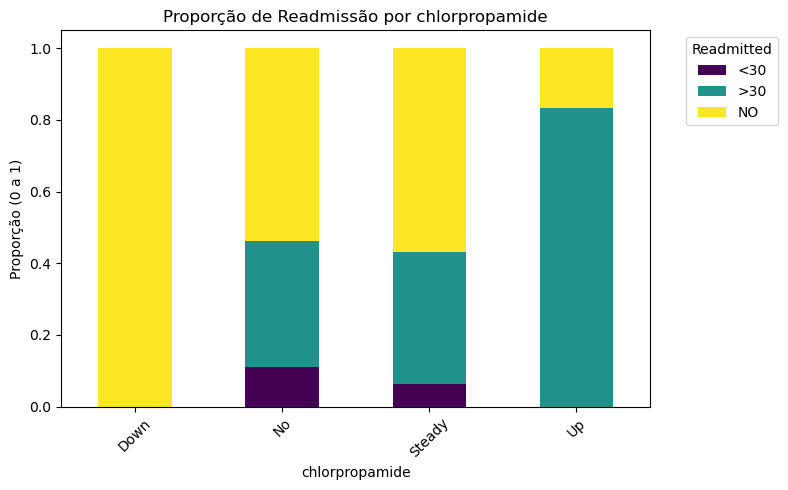

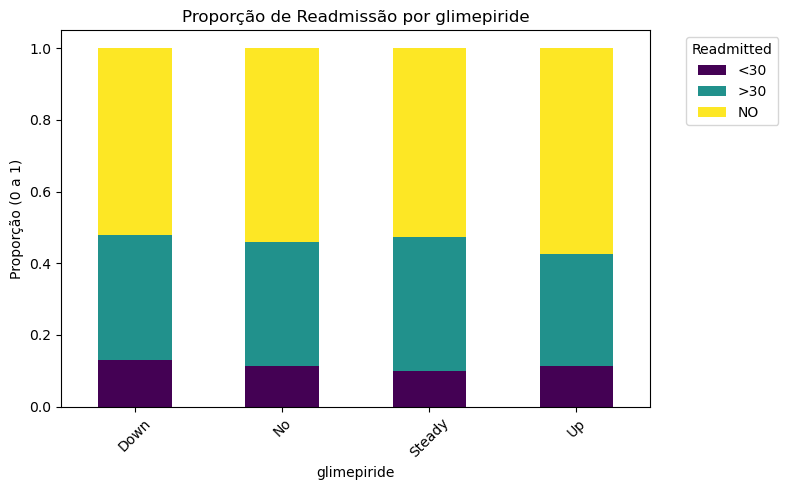

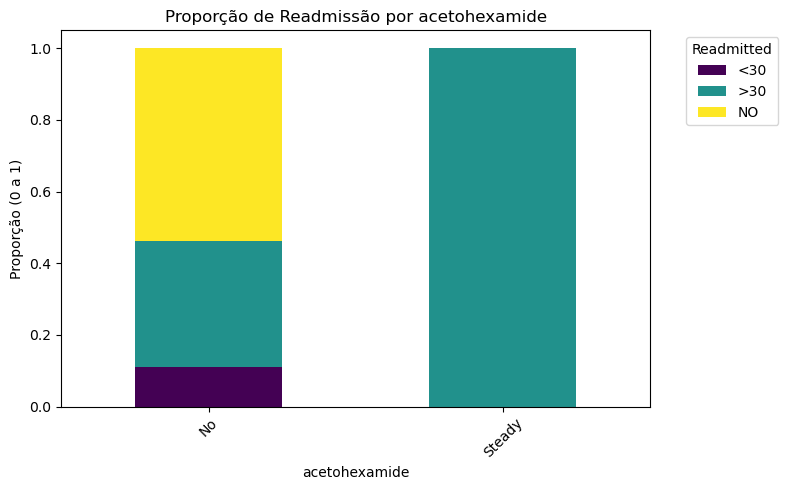

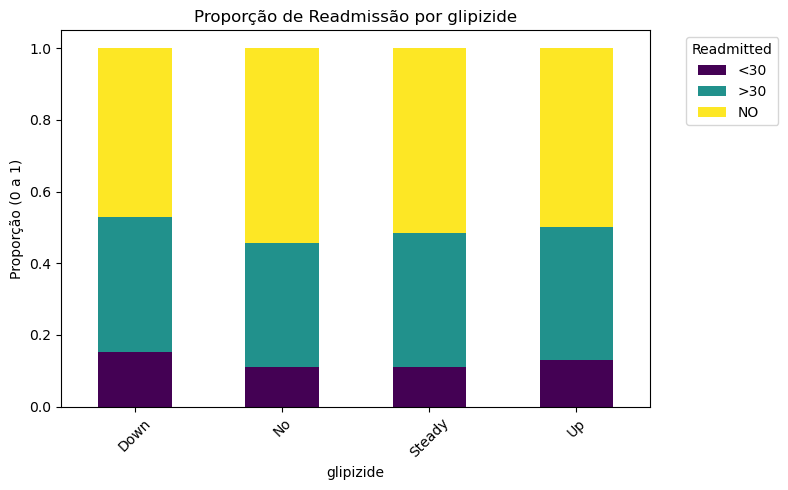

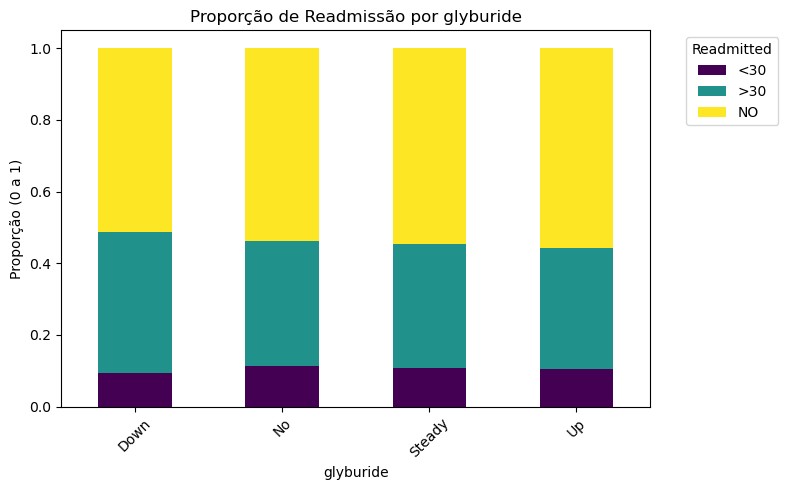

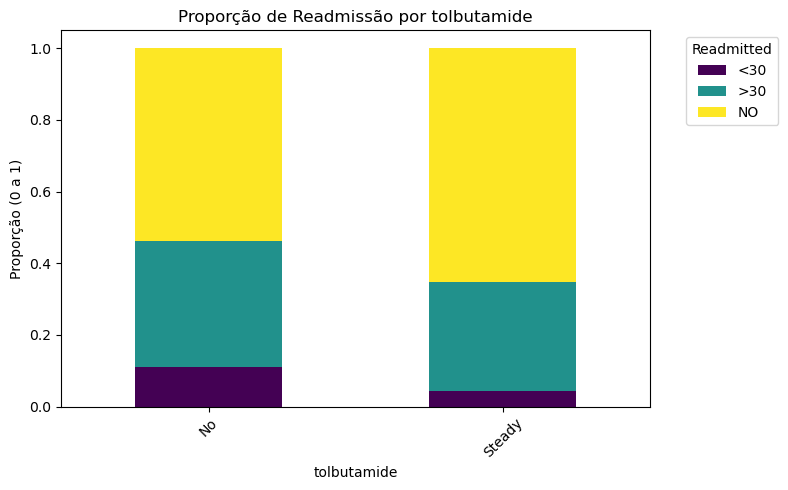

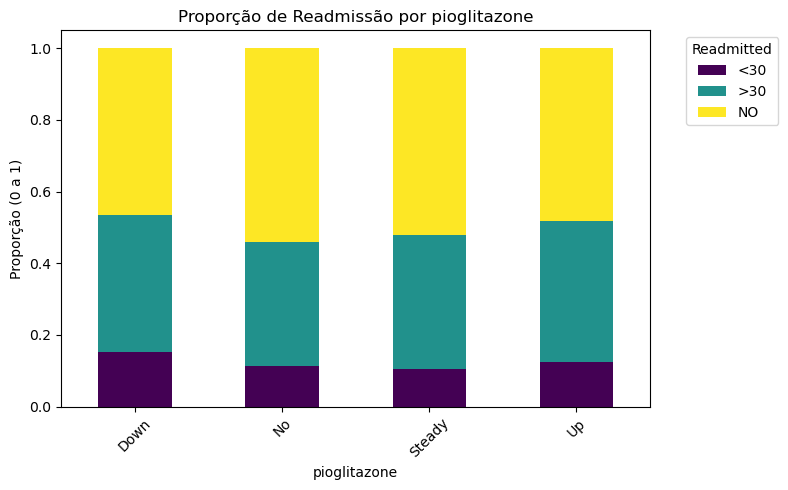

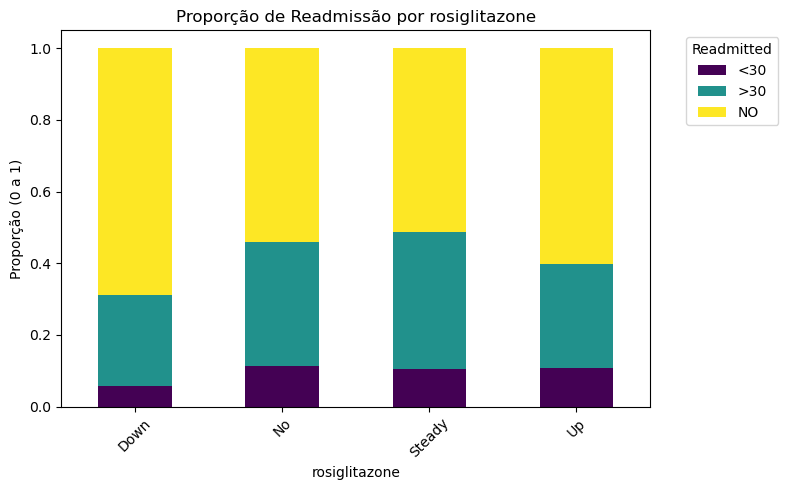

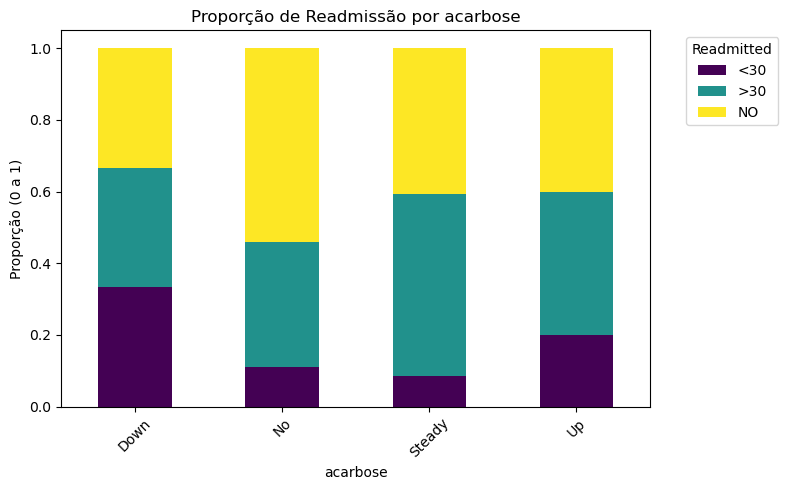

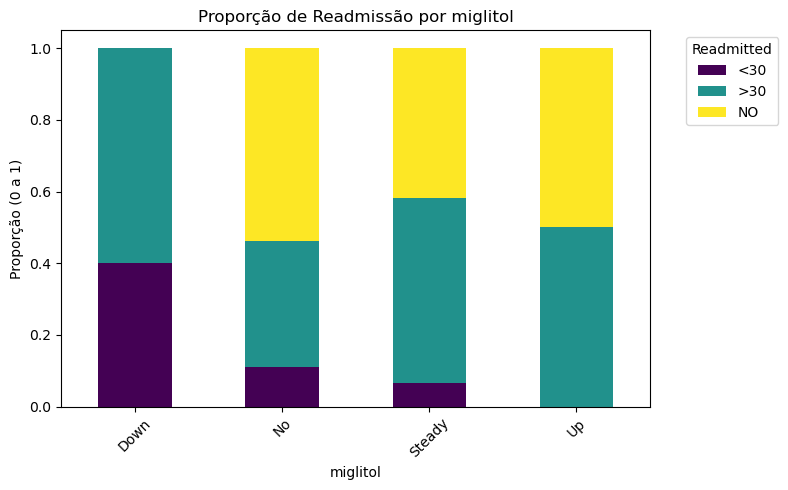

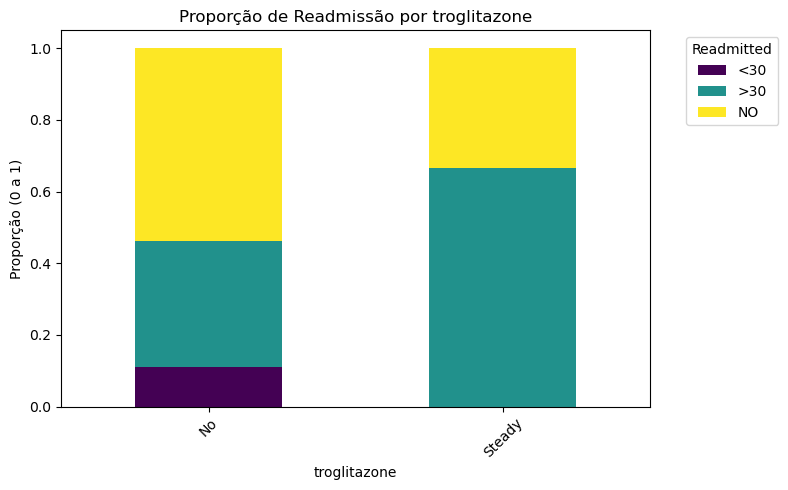

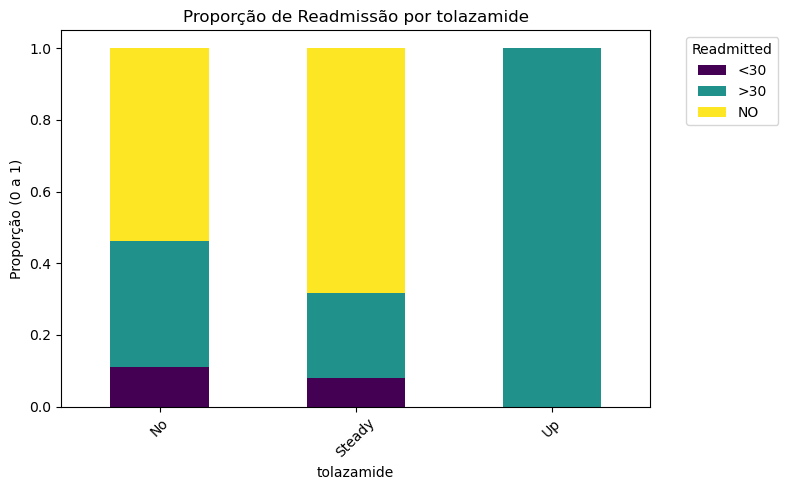

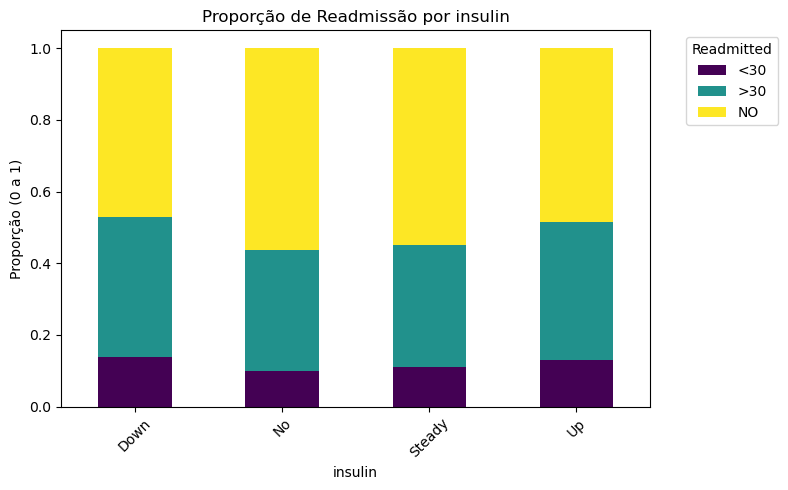

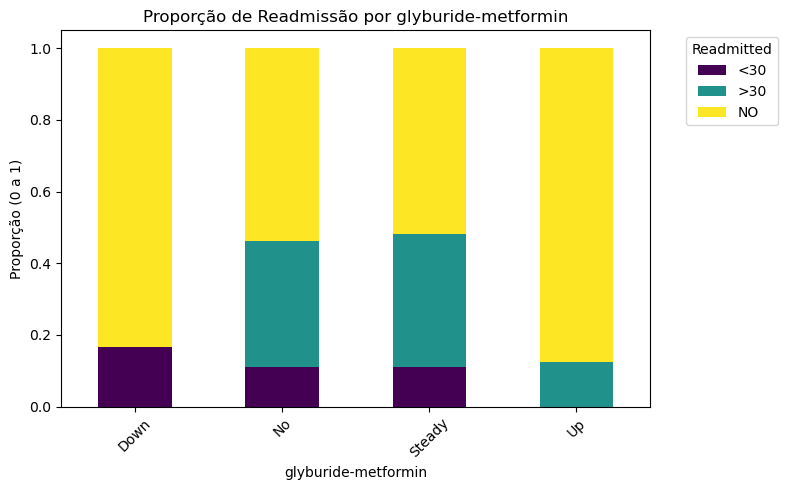

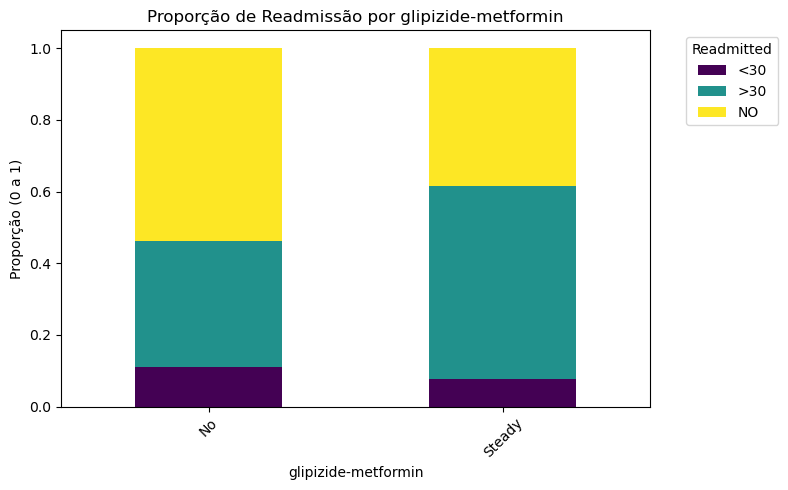

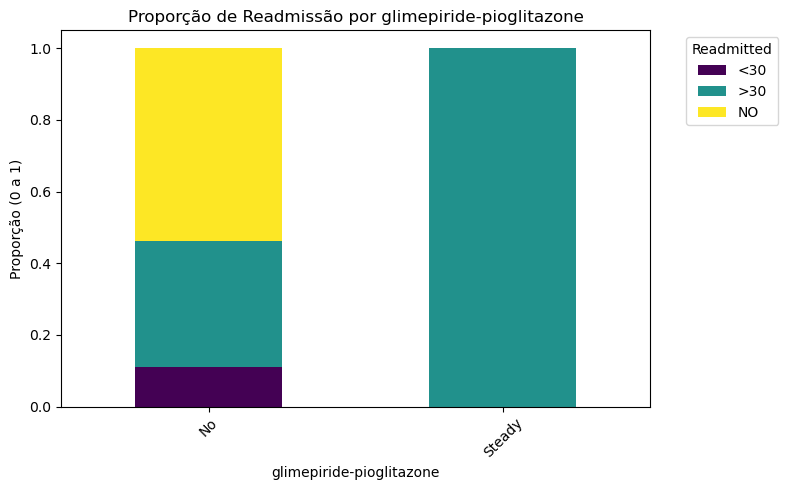

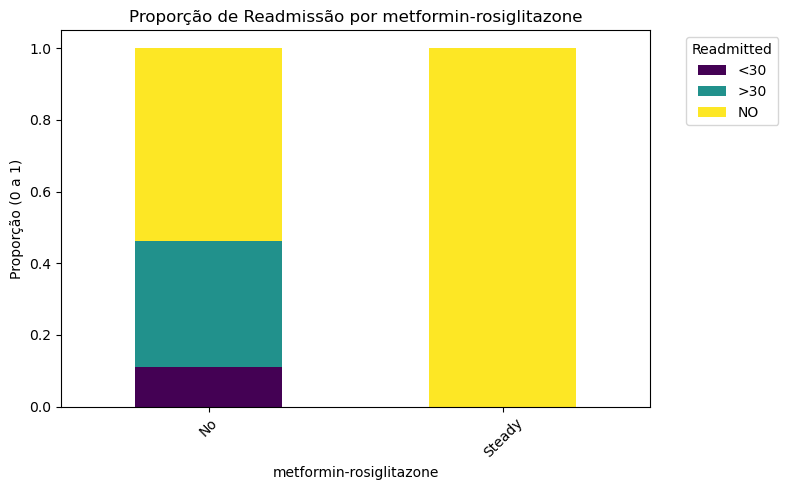

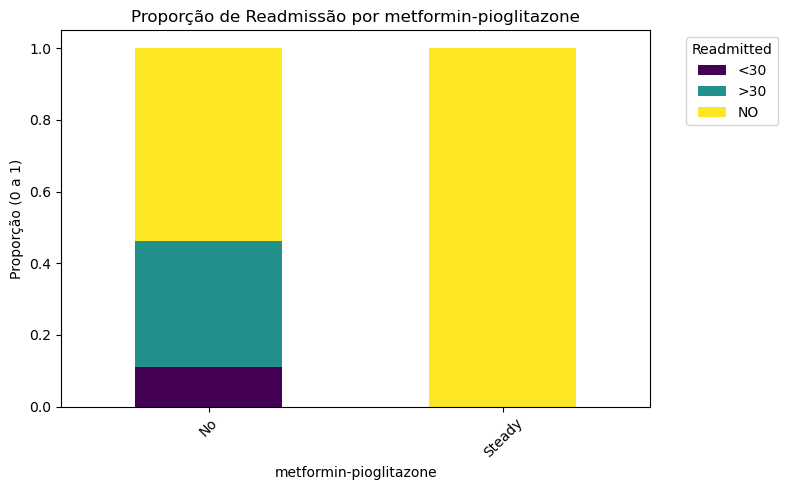

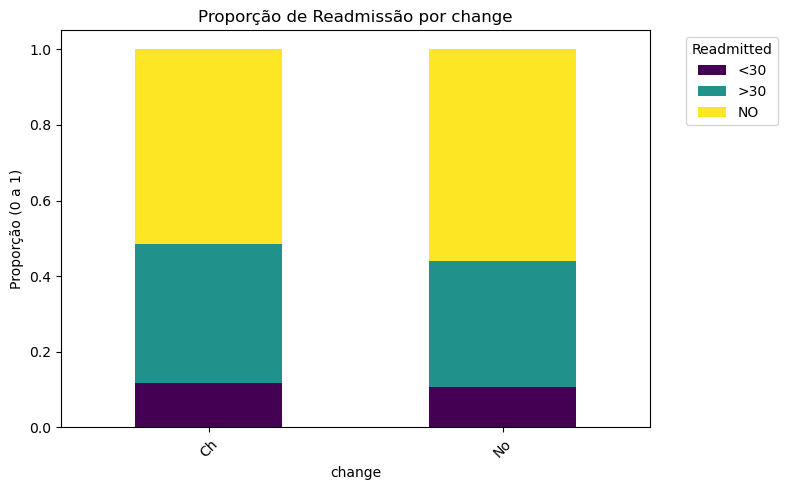

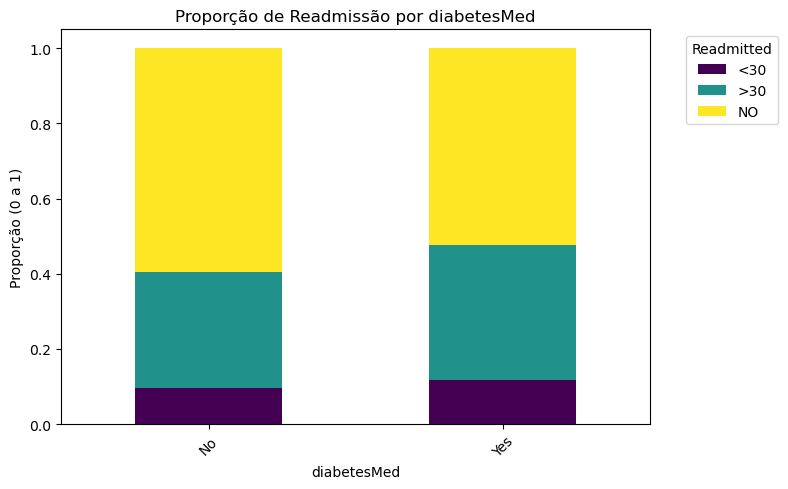

In [38]:
for col in categorical_df.columns:
    if col != 'readmitted':
        crosstab = pd.crosstab(categorical_df[col], categorical_df['readmitted'], normalize='index')
        
        crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
        
        plt.title(f'Proporção de Readmissão por {col}')
        plt.ylabel('Proporção (0 a 1)')
        plt.xlabel(col)
        plt.legend(title='Readmitted', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [45]:
def pairwise_proportion_test(dataframe, cat_col, target_col='readmitted', success_class='<30'):
    resultados = []
    
    categorias = dataframe[cat_col].dropna().unique()
    
    if len(categorias) > 15:
        return pd.DataFrame([{"Erro": f"Muitas categorias em {cat_col} para teste pareado."}])

    pares = list(combinations(categorias, 2))
    
    num_comparacoes = len(pares)
    alpha_ajustado = 0.05 / num_comparacoes if num_comparacoes > 0 else 0.05
    
    for cat1, cat2 in pares:
        grupo1 = dataframe[dataframe[cat_col] == cat1][target_col]
        grupo2 = dataframe[dataframe[cat_col] == cat2][target_col]
        
        sucessos = np.array([(grupo1 == success_class).sum(), (grupo2 == success_class).sum()])
        total = np.array([len(grupo1), len(grupo2)])
        
        if total[0] == 0 or total[1] == 0:
            continue
            
        stat, p_val = proportions_ztest(count=sucessos, nobs=total)
        
        prop1 = sucessos[0] / total[0]
        prop2 = sucessos[1] / total[1]
        
        resultados.append({
            'Variável': cat_col,
            'Comparação': f'{cat1} vs {cat2}',
            f'Prop. {cat1}': prop1,
            f'Prop. {cat2}': prop2,
            'Diferença Absoluta': abs(prop1 - prop2),
            'P-Valor': p_val,
            f'Significativo (Bonferroni α={alpha_ajustado:.4f})': p_val < alpha_ajustado 
        })
        
    return pd.DataFrame(resultados).sort_values(by='P-Valor')

In [46]:
for col in categorical_df.columns:
    if col != 'readmitted': 
        df_teste_z = pairwise_proportion_test(df, col, target_col='readmitted', success_class='<30')
        display(df_teste_z)

,Variável,Comparação,Prop. Caucasian,Prop. AfricanAmerican,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0033),Prop. ?,Prop. Other,Prop. Asian,Prop. Hispanic
1,race,Caucasian vs ?,0.112906,NaN,0.030195,0.000007,True,0.08271,NaN,NaN,NaN
5,race,AfricanAmerican vs ?,NaN,0.112181,0.029471,0.000020,True,0.08271,NaN,NaN,NaN
11,race,? vs Hispanic,NaN,NaN,0.021365,0.015809,False,0.08271,NaN,NaN,0.104075
2,race,Caucasian vs Other,0.112906,NaN,0.016624,0.043267,False,NaN,0.096282,NaN,NaN
6,race,AfricanAmerican vs Other,NaN,0.112181,0.015900,0.058588,False,NaN,0.096282,NaN,NaN
10,race,? vs Asian,NaN,NaN,0.018694,0.137665,False,0.08271,NaN,0.101404,NaN
9,race,? vs Other,NaN,NaN,0.013571,0.149600,False,0.08271,0.096282,NaN,NaN
4,race,Caucasian vs Hispanic,0.112906,NaN,0.008831,0.213510,False,NaN,NaN,NaN,0.104075
8,race,AfricanAmerican vs Hispanic,NaN,0.112181,0.008107,0.268850,False,NaN,NaN,NaN,0.104075
3,race,Caucasian vs Asian,0.112906,NaN,0.011502,0.359351,False,NaN,NaN,0.101404,NaN


,Variável,Comparação,Prop. Female,Prop. Male,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0167),Prop. Unknown/Invalid
0,gender,Female vs Male,0.112452,0.110615,0.001836,0.353636,False,NaN
1,gender,Female vs Unknown/Invalid,0.112452,NaN,0.112452,0.537553,False,0.0
2,gender,Male vs Unknown/Invalid,NaN,0.110615,0.110615,0.541311,False,0.0


,Variável,Comparação,Prop. [0-10),Prop. [10-20),Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0011),Prop. [20-30),Prop. [30-40),Prop. [40-50),Prop. [50-60),Prop. [60-70),Prop. [70-80),Prop. [80-90),Prop. [90-100)
37,age,[50-60) vs [80-90),NaN,NaN,0.024173,5.731406e-13,True,NaN,NaN,NaN,0.096662,NaN,NaN,0.120835,NaN
36,age,[50-60) vs [70-80),NaN,NaN,0.021069,6.010873e-12,True,NaN,NaN,NaN,0.096662,NaN,0.117731,NaN,NaN
19,age,[20-30) vs [50-60),NaN,NaN,0.045764,3.344034e-09,True,0.142426,NaN,NaN,0.096662,NaN,NaN,NaN,NaN
9,age,[10-20) vs [20-30),NaN,0.057887,0.084539,6.776210e-09,True,0.142426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,age,[10-20) vs [80-90),NaN,0.057887,0.062948,5.122235e-07,True,NaN,NaN,NaN,NaN,NaN,NaN,0.120835,NaN
14,age,[10-20) vs [70-80),NaN,0.057887,0.059843,1.264369e-06,True,NaN,NaN,NaN,NaN,NaN,0.117731,NaN,NaN
35,age,[50-60) vs [60-70),NaN,NaN,0.014622,2.426352e-06,True,NaN,NaN,NaN,0.096662,0.111284,NaN,NaN,NaN
1,age,[0-10) vs [20-30),0.018634,NaN,0.123793,9.084923e-06,True,0.142426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,age,[10-20) vs [60-70),NaN,0.057887,0.053397,9.684596e-06,True,NaN,NaN,NaN,NaN,0.111284,NaN,NaN,NaN
18,age,[20-30) vs [40-50),NaN,NaN,0.036386,1.355901e-05,True,0.142426,NaN,0.10604,NaN,NaN,NaN,NaN,NaN


,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0083),Prop. Up,Prop. Down
0,metformin,No vs Steady,0.115165,0.097133,0.018033,2.501717e-12,True,NaN,NaN
1,metformin,No vs Up,0.115165,NaN,0.032691,8.719546e-04,True,0.082474,NaN
5,metformin,Up vs Down,NaN,NaN,0.037526,1.363581e-02,False,0.082474,0.12
4,metformin,Steady vs Down,NaN,0.097133,0.022867,6.914472e-02,False,NaN,0.12
3,metformin,Steady vs Up,NaN,0.097133,0.014659,1.146375e-01,False,0.082474,NaN
2,metformin,No vs Down,0.115165,NaN,0.004835,7.174687e-01,False,NaN,0.12


,Variável,Comparação,Prop. No,Prop. Up,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0083),Prop. Steady,Prop. Down
1,repaglinide,No vs Steady,0.111267,NaN,0.020235,0.017549,False,0.131503,NaN
0,repaglinide,No vs Up,0.111267,0.181818,0.070551,0.018721,False,NaN,NaN
4,repaglinide,Up vs Down,NaN,0.181818,0.115152,0.067164,False,NaN,0.066667
3,repaglinide,Up vs Steady,NaN,0.181818,0.050315,0.137448,False,0.131503,NaN
5,repaglinide,Steady vs Down,NaN,NaN,0.064836,0.202307,False,0.131503,0.066667
2,repaglinide,No vs Down,0.111267,NaN,0.044601,0.341454,False,NaN,0.066667


...

,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,glimepiride-pioglitazone,No vs Steady,0.1116,0.0,0.1116,0.723018,False


,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,metformin-rosiglitazone,No vs Steady,0.111601,0.0,0.111601,0.616203,False


,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,metformin-pioglitazone,No vs Steady,0.1116,0.0,0.1116,0.723018,False


,Variável,Comparação,Prop. No,Prop. Ch,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,change,No vs Ch,0.105908,0.118228,0.01232,4.891176e-10,True


,Variável,Comparação,Prop. No,Prop. Yes,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,diabetesMed,No vs Yes,0.095971,0.116267,0.020296,5.017335e-18,True
